In [1]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import sys 

import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint
import generate_data
from datasets import LetterStringDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Comparisons

In [2]:
unstructured = CheckPoint.from_pt(path="../models/copy_batching_strategies/MLC_batchunstruct_dallstudy1_incl_copy_fixedgen_nep20.pt")
by_trans = CheckPoint.from_pt(path="../models/copy_batching_strategies/MLC_batchtrans_dallstudy1_incl_copy_fixedgen_nep20.pt")
by_alph = CheckPoint.from_pt(path="../models/copy_batching_strategies/MLC_batchalph_dallstudy1_incl_copy_fixedgen_nep20.pt")
by_both = CheckPoint.from_pt(path="../models/copy_batching_strategies/MLC_batchbyboth_dallstudy1_incl_copy_fixedgen_nep20.pt")
all_training_runs = [unstructured, by_trans, by_alph, by_both]

In [3]:
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["loss"] = round(train_run.best_val_loss, 3)
    data[i]["accuracy in-dist"] = round(np.max([x["in"] for x in train_run.val_acc_hist]), 3)
    data[i]["accuracy out-of-dist"] = round(np.max([x["out-of"] for x in train_run.val_acc_hist]), 3)
df = pd.DataFrame(data)
print("Shared Training Configuration:")
shared_arguments = df.loc[:, df.nunique() == 1].drop(["dir_model", "save_best", "save_best_skip"], axis=1).rename(columns={"dir_data": "dataset"})
shared_arguments.loc[0,:].to_markdown("copy_batching_shared_params.md")
shared_arguments.loc[0,:]

Shared Training Configuration:


dataset            data/all_transformations_study1_incl_copy_fixe...
batch_size                                                        32
query_first                                                    False
nepochs                                                           20
lr                                                             0.001
lr_end_factor                                                   0.05
lr_warmup                                                       True
hidden_size                                                      128
input_size                                                        30
output_size                                                       30
PAD_idx_input                                                     28
PAD_idx_output                                                    28
nlayers_encoder                                                    3
nlayers_decoder                                                    3
nhead                             

In [4]:
print("Differences in Configuration and Results:")
df.loc[:, df.nunique() > 1].to_markdown("copy_batching_results.md", index=False) # save results table
df.loc[:, df.nunique() > 1]

Differences in Configuration and Results:


,filename_model,batching_method,loss,accuracy in-dist,accuracy out-of-dist
0,MLC_batchunstruct_dallstudy1_incl_copy_fixedge...,unstructured,0.708,0.887,0.131
1,MLC_batchtrans_dallstudy1_incl_copy_fixedgen_n...,transformation,0.715,0.886,0.140
2,MLC_batchalph_dallstudy1_incl_copy_fixedgen_ne...,alphabet,0.685,0.899,0.142
3,MLC_batchbyboth_dallstudy1_incl_copy_fixedgen_...,both,0.703,0.894,0.133


### Split by copy, transformation

#### Unstructured

In [ ]:
val_un = unstructured.load_dataloaders(f"../{unstructured.train_config.dir_data}", use_datasets=["val"], batch_size=10_000)[0]
model_un = unstructured.load_model()

pred_un = analysis_utils.predict_dataset(val_un, model_un, alternative_rule_errors=False)

In [30]:
def get_accuracies_from_predictions(pred, verbose=True):
    """Generate Accuracies by copy, in-/out-of-distribution, generalization, and transformation type.

    Args:
        pred (pd.DataFrame): Dataframe containing model predictions. Generated from `analysis_utils.predict_dataset`.
                                Note: the pred dataframe must contain columns ["copy", "distribution", "transformation", "generalization_type", "correct"].
    """
    required_columns = ["copy", "distribution", "transformation", "generalization_type", "correct"]
    assert(all([required_column in pred.columns for required_column in required_columns]))
    
    accs = dict()
    accs["overall"] = np.mean(pred.correct)

    pred_noncopy = pred[~pred["copy"]]
    pred_copy = pred[pred["copy"]]
    accs["noncopy"] = np.mean(pred_noncopy.correct)
    accs["noncopy in-dist (rules in train set)"] = np.mean(pred_noncopy[pred_noncopy.distribution == "in"]["correct"])
    accs["copy in-dist (rules in train set)"] = np.mean(pred_copy[pred_copy["distribution"]=="in"]["correct"])
    accs["noncopy out-of-dist (rules NOT in train set)"] = np.mean(pred_noncopy[pred_noncopy.distribution == "out-of"]["correct"])
    accs["copy out-of-dist (rules NOT in train set)"] = np.mean(pred_copy[pred_copy["distribution"]=="out-of"]["correct"])
    accs["noncopy (generalization type 2)"] = np.mean(pred[pred.generalization_type==2.0].correct)
    accs["noncopy by transformation type"] = pred_noncopy.groupby("transformation")["correct"].mean()

    if verbose:
        print("Validation Accuracies from training with copy tasks (query is the same as study example)\n-------------------------------------------------------------------------------------------")
        for key, value in accs.items():
            if key != "noncopy by transformation type":
                print(f"{key}: {value:.3f}")

        print("\nValidation Accuracies noncopy by transformation type:\n-------------------------------------------------------------------------------------------")
        print(accs["noncopy by transformation type"].round(3))
    return accs

accs_pred_un = get_accuracies_from_predictions(pred_un)

Validation Accuracies from training with copy tasks (query is the same as study example)
-------------------------------------------------------------------------------------------
overall: 0.631
noncopy: 0.521
noncopy in-dist (rules in train set): 0.870
copy in-dist (rules in train set): 0.999
noncopy out-of-dist (rules NOT in train set): 0.129
copy out-of-dist (rules NOT in train set): 0.452
noncopy (generalization type 2): 0.402

Validation Accuracies noncopy by transformation type:
-------------------------------------------------------------------------------------------
transformation
extend_extend_succ    0.001
extend_group          0.015
extend_pred           0.020
extend_sequence       0.830
fix_alphabetic_seq    0.635
fix_extend            0.737
fix_interleave        0.426
fix_pred_succ         0.000
pred                  0.772
remove_redundant      1.000
replicate             0.000
reverse               0.000
rr_interleave         1.000
rr_sort               0.652
rr_succ   

In [ ]:
pred_un = analysis_utils.predict_dataset(val_un, model_un, alternative_rule_errors=False)

In [10]:
df_noncopy = pd.DataFrame(columns=["batching_method", "loss", "accuracy in-dist", "accuracy out-of-dist"])
val_un = unstructured.load_dataloaders(f"../{unstructured.train_config.dir_data}", use_datasets=["val"], val_batch_size=10_000)[0]
for i, cp in enumerate(all_training_runs):
    model = cp.load_model()
    pred = analysis_utils.predict_dataset(val_un, model, alternative_rule_errors=False)

    pred_noncopy = pred[~pred["copy"]]
    pred_copy = pred[pred["copy"]]
    val_acc_in = np.mean(pred_noncopy[pred_noncopy.distribution == "in"]["correct"])
    val_acc_out_of = np.mean(pred_noncopy[pred_noncopy.distribution == "out-of"]["correct"])
    df_noncopy.loc[i,:] = [cp.train_config.batching_method, cp.best_val_loss, val_acc_in, val_acc_out_of]

Loaded following dataloaders:
val dataloader (n=46,158)
Loading model that has completed 20 of 20 epochs
	batch size: 32
	number of steps: 230,800
	best val loss achieved: 0.7083
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Predicting:   0%|          | 0/4 [00:00<?, ?it/s]c:\Users\13579681\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
Predicting: 5it [32:52, 394.52s/it]                       


Loading model that has completed 20 of 20 epochs
	batch size: 32
	number of steps: 230,900
	best val loss achieved: 0.7154
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Predicting: 5it [19:40, 236.06s/it]                       


Loading model that has completed 20 of 20 epochs
	batch size: 32
	number of steps: 230,960
	best val loss achieved: 0.6848
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Predicting: 5it [21:04, 252.90s/it]                       


Loading model that has completed 20 of 20 epochs
	batch size: 32
	number of steps: 232,740
	best val loss achieved: 0.7026
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Predicting: 5it [23:26, 281.28s/it]                       


In [11]:
df_noncopy

,batching_method,loss,accuracy in-dist,accuracy out-of-dist
0,unstructured,0.708269,0.870093,0.129217
1,transformation,0.715363,0.869109,0.124793
2,alphabet,0.684801,0.899107,0.132811
3,both,0.702639,0.873207,0.125806


In [12]:
df_noncopy.to_markdown("copy_batching_noncopy_accs.md", index=False)

### New alphabets

In [27]:
new_alphs = pd.read_csv("../data/all_transformations_study1_new_alphabets/test.csv")
old_alphs = pd.DataFrame(val_un.dataset.data)
# check whether there is alphabet overlap
set(new_alphs.alphabet.unique()) & set(old_alphs.alphabet.unique())

{'a b c d e f g h i j k l m n o p q r s t u v w x y z'}

In [33]:
df_new_alphabets = pd.DataFrame(columns=["batching_method", "accuracy in-dist", "accuracy out-of-dist"])
for i, cp in enumerate(all_training_runs):
    val_new_alph = cp.load_dataloaders("../data/all_transformations_study1_new_alphabets", use_datasets=["test"], val_batch_size=10_000)[0]
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(val_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    val_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    val_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    df_new_alphabets.loc[i,:] = [cp.train_config.batching_method, val_acc_in, val_acc_out_of]


Loaded following dataloaders:
test dataloader (n=11,490)


Predicting: 360it [04:21,  1.37it/s]                         


Loaded following dataloaders:
test dataloader (n=11,490)


Predicting: 368it [21:23,  3.49s/it]                         


Loaded following dataloaders:
test dataloader (n=11,490)


Predicting: 370it [25:24,  4.12s/it]                         


Loaded following dataloaders:
test dataloader (n=11,490)


Predicting: 525it [06:40,  1.31it/s]                         


In [35]:
df_new_alphabets.round(3)

,batching_method,accuracy in-dist,accuracy out-of-dist
0,unstructured,0.367149,0.053451
1,transformation,0.37494,0.056912
2,alphabet,0.388138,0.053836
3,both,0.37653,0.055374


In [36]:
df_new_alphabets.to_markdown("copy_batching_new_alphabets_accs.md", index=False)

### Lewis & Mitchell data:

In [7]:
df_lm = pd.DataFrame(columns=["batching_method", "accuracy in-dist"])
for i, cp in enumerate(all_training_runs):
    val_new_alph = cp.load_dataloaders("../data/lewis_mitchell", use_datasets=["test"], val_batch_size=10, verbose=False)[0]
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(val_new_alph, model, alternative_rule_errors=False)
    val_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    df_lm.loc[i,:] = [cp.train_config.batching_method, val_acc_in]
df_lm

Predicting: 65it [00:12,  5.07it/s]                        
Predicting: 66it [00:12,  5.15it/s]                        
Predicting: 69it [00:20,  3.39it/s]                        
Predicting: 184it [00:23,  7.95it/s]                       


,batching_method,accuracy in-dist
0,unstructured,0.364117
1,transformation,0.363636
2,alphabet,0.389129
3,both,0.363155


### Individual Training Histories

Loaded following dataloaders:
val dataloader (n=46,158)
Training information:
Best Validation Loss: 0.708
Best Validation Accuracy: 0.639


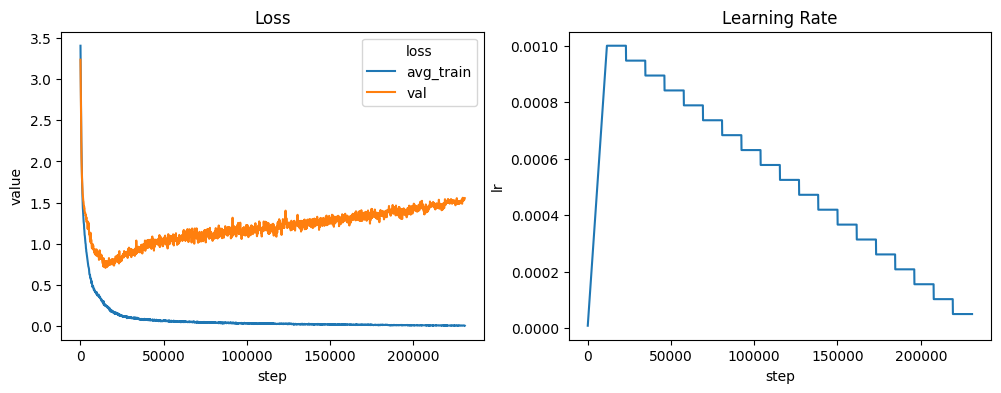

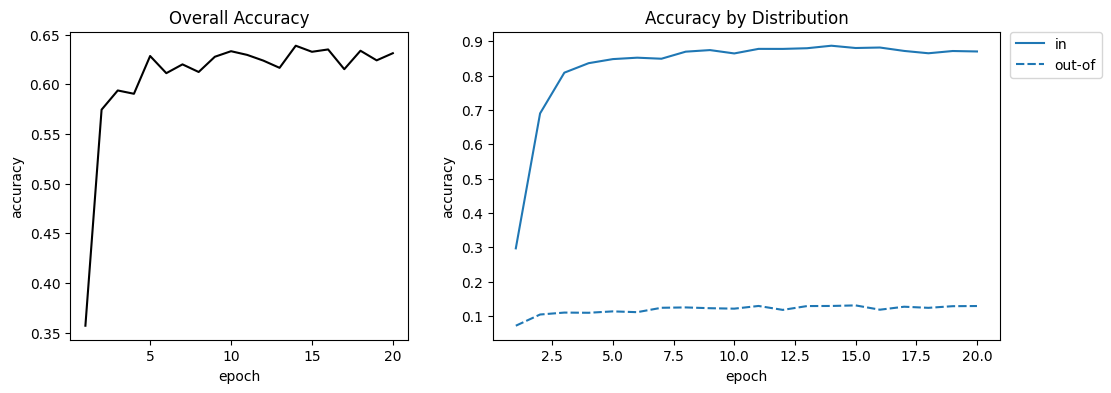

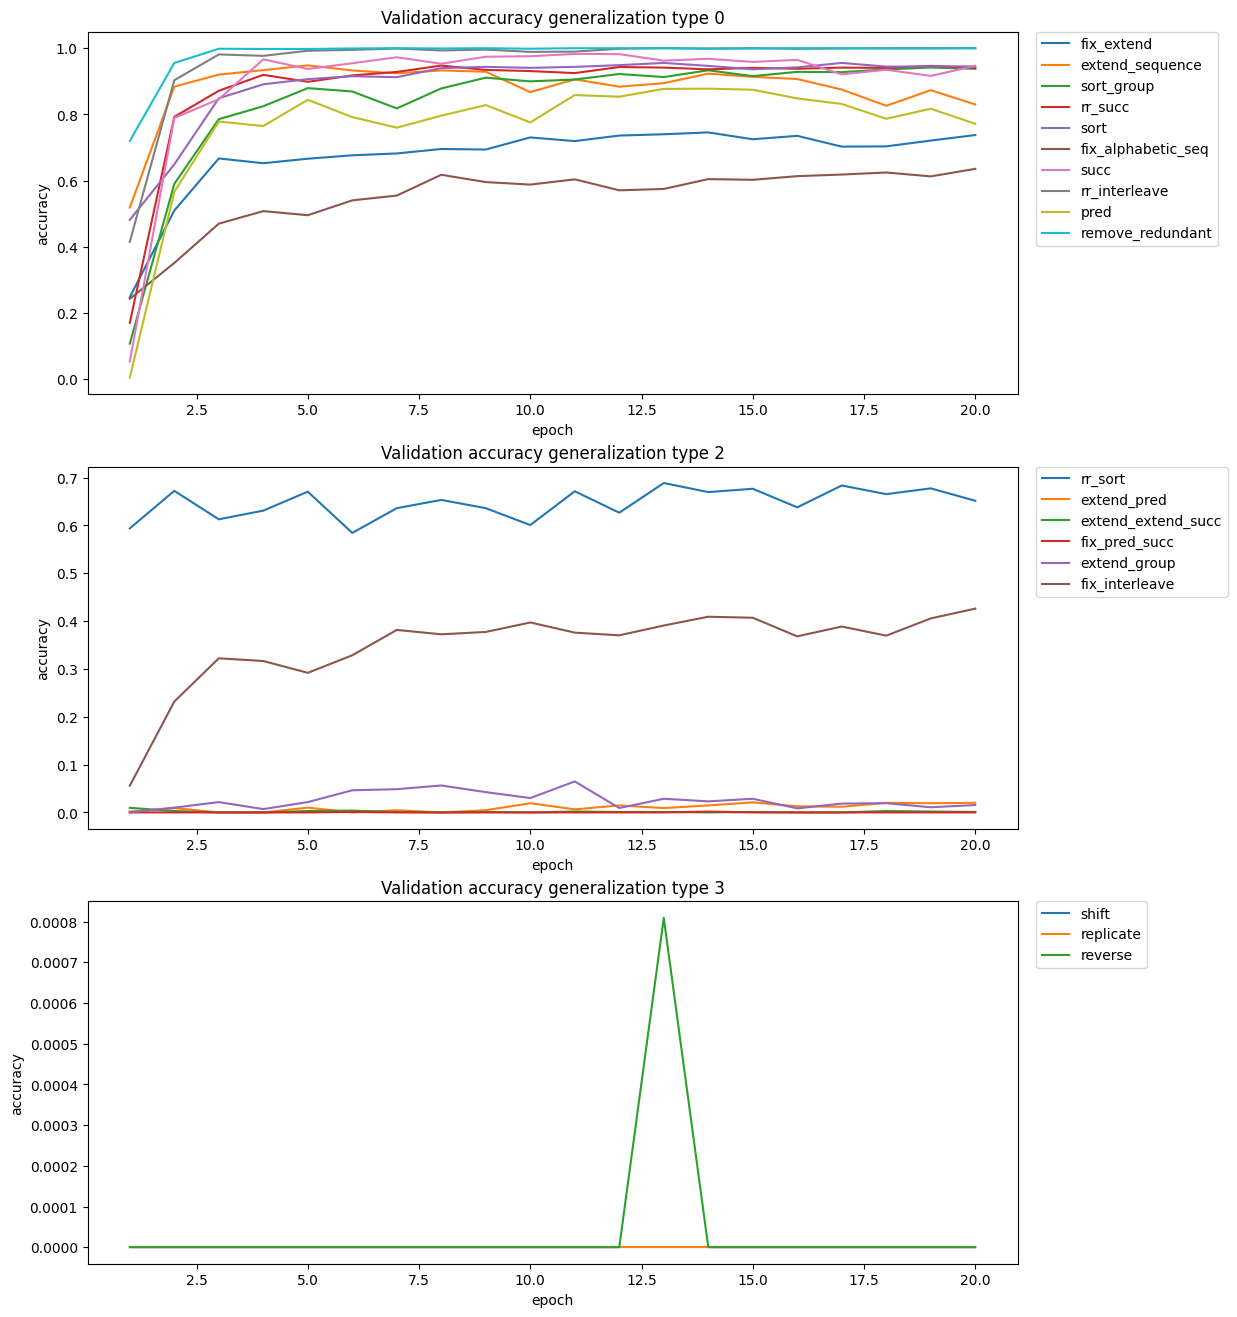

In [ ]:
val_loader = unstructured.load_dataloaders(f"../{unstructured.train_config.dir_data}", use_datasets=["val"])[0]
_ = analysis_utils.training_information(unstructured, val_loader, "Training History, Batching: unstructured")

Training information:
Best Validation Loss: 0.715
Best Validation Accuracy: 0.658


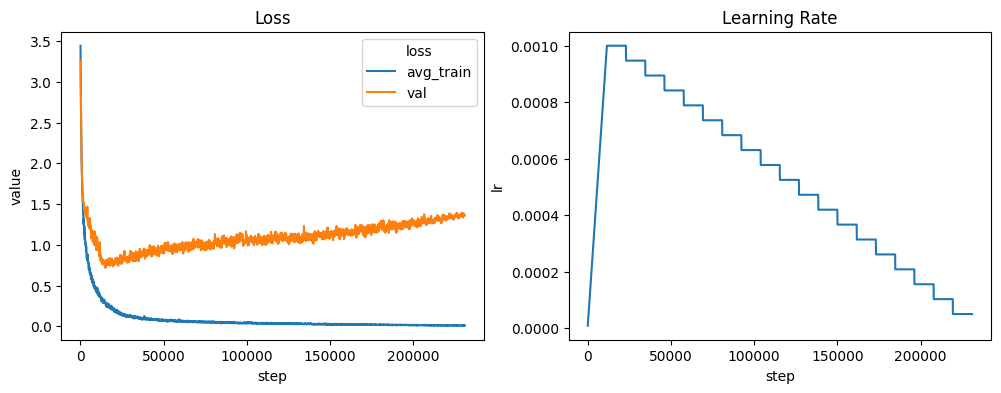

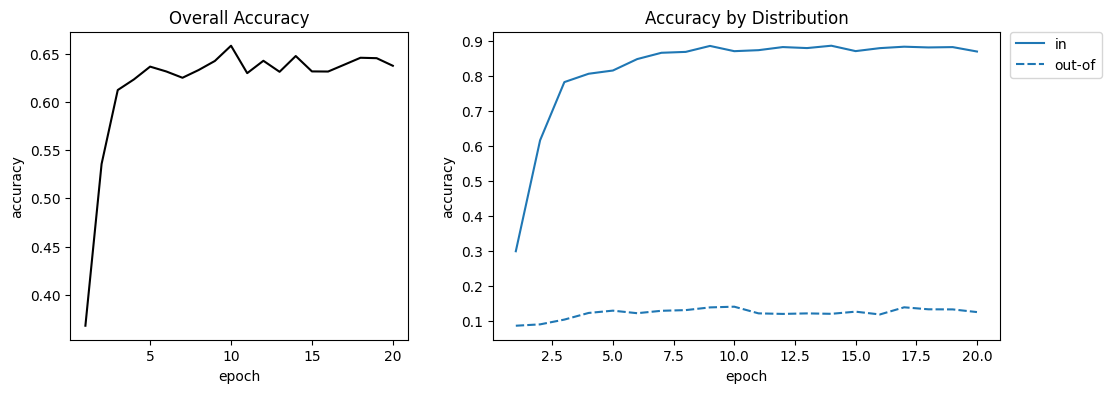

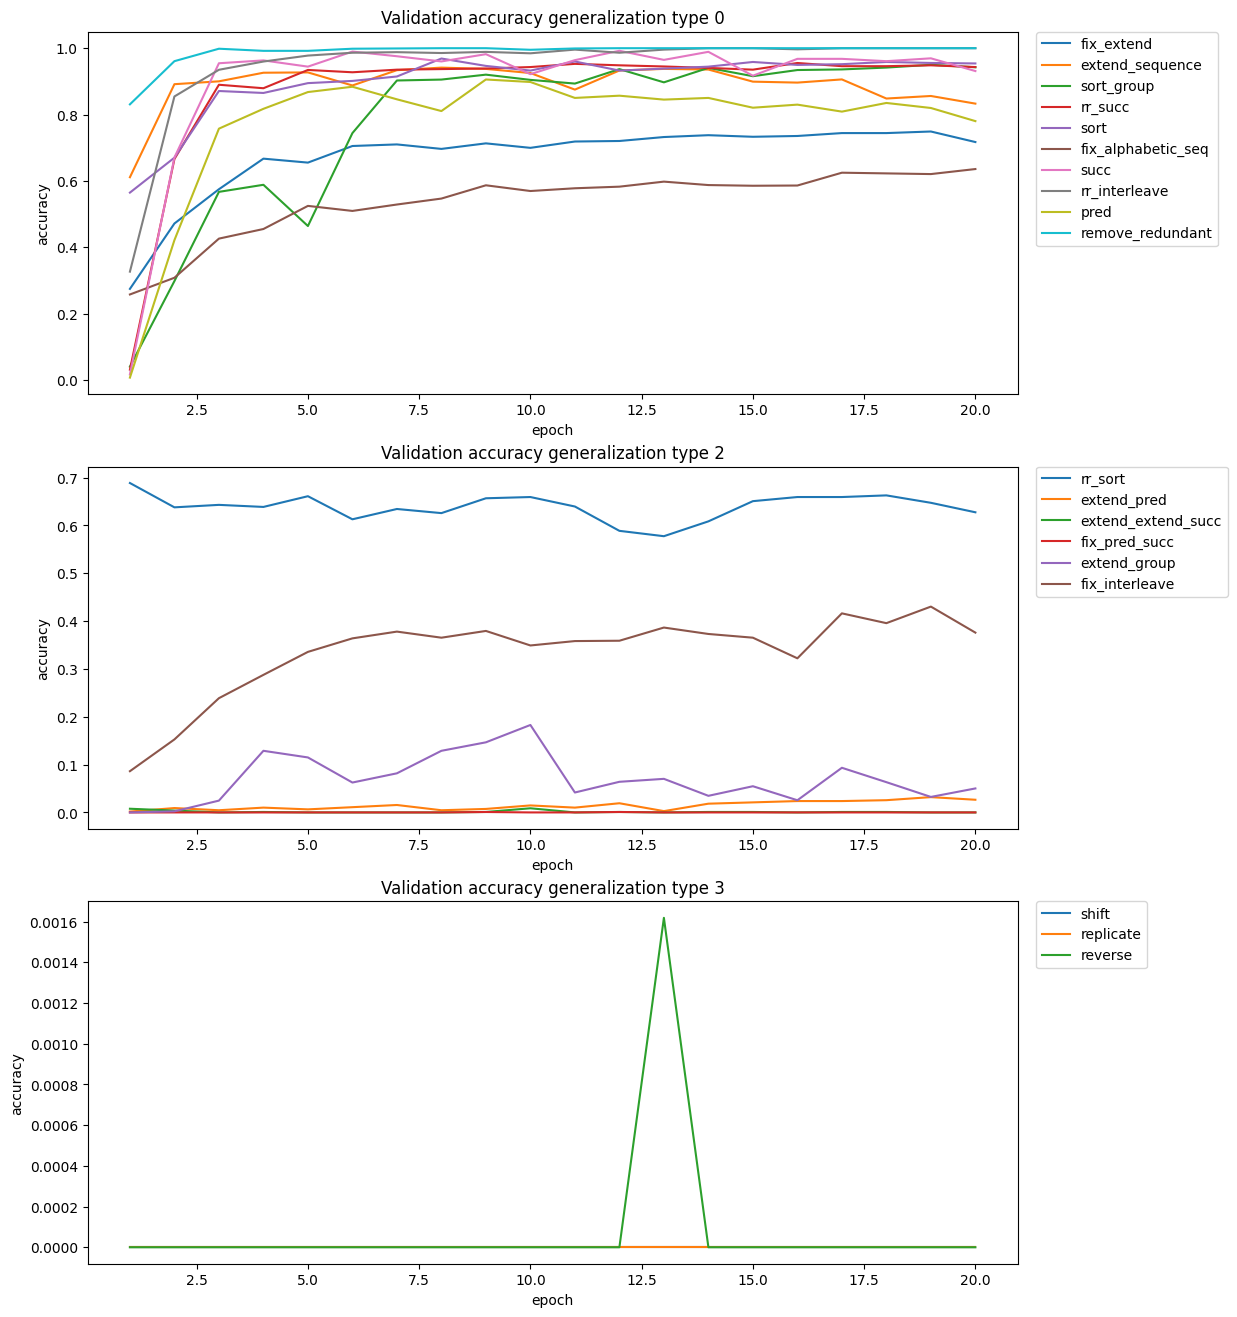

In [ ]:
_ = analysis_utils.training_information(by_trans, val_loader, "Training History, Batching: unstructured")

Training information:
Best Validation Loss: 0.685
Best Validation Accuracy: 0.640


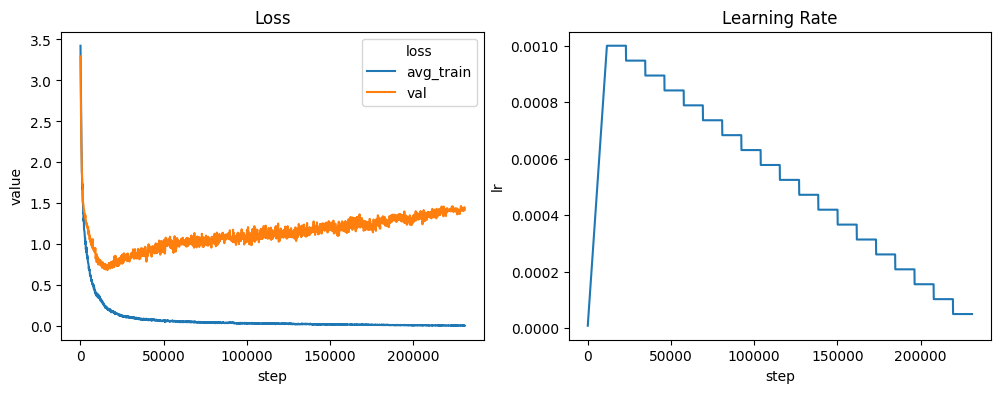

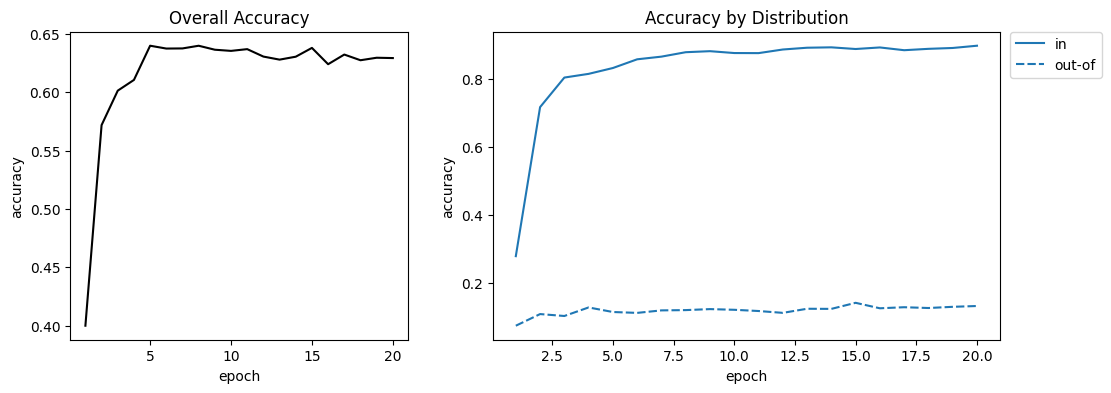

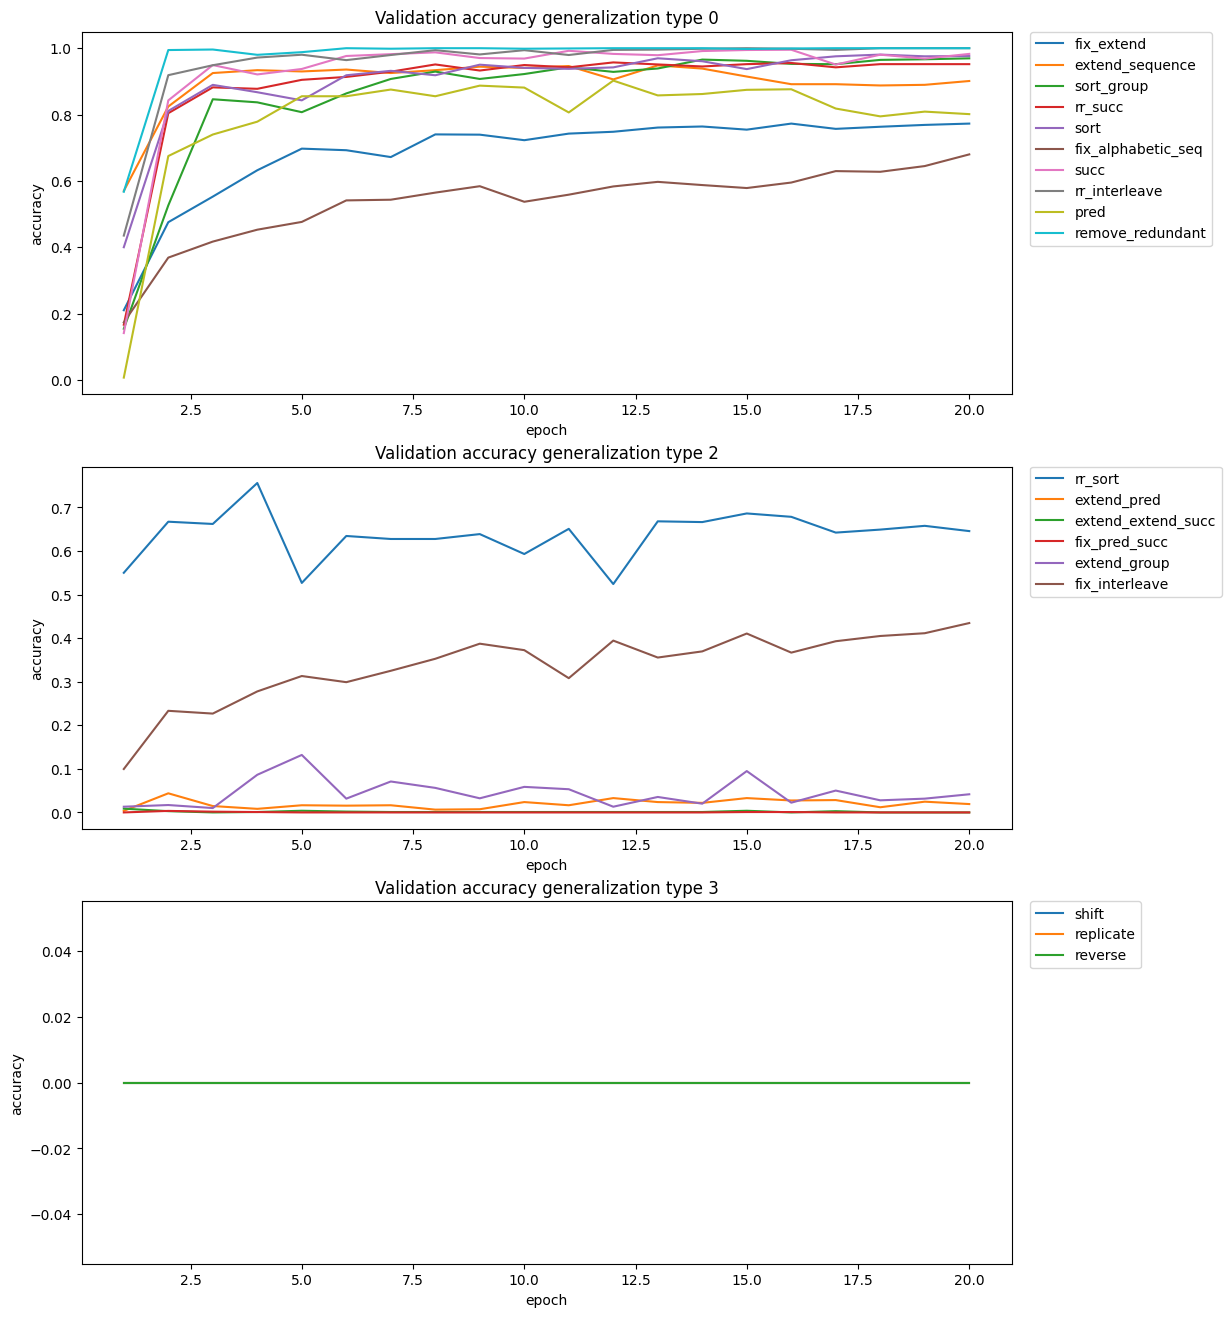

In [ ]:
_ = analysis_utils.training_information(by_alph, val_loader, "Training History, Batching: unstructured")

Training information:
Best Validation Loss: 0.703
Best Validation Accuracy: 0.652


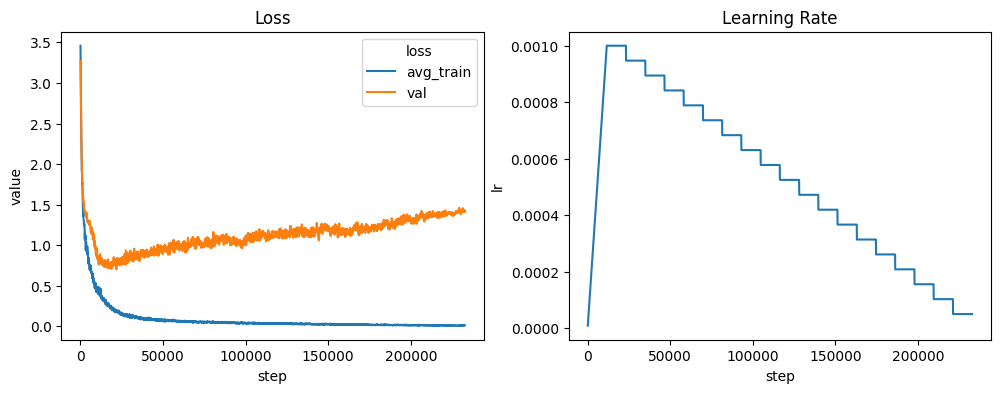

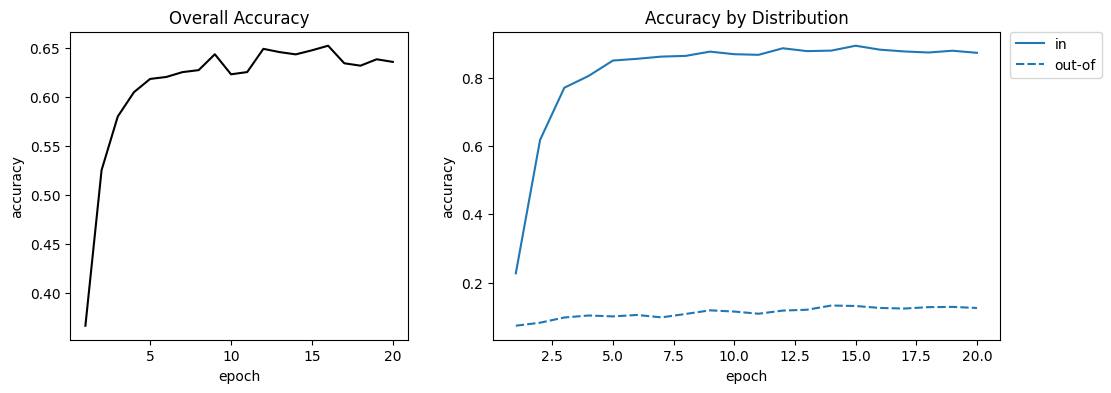

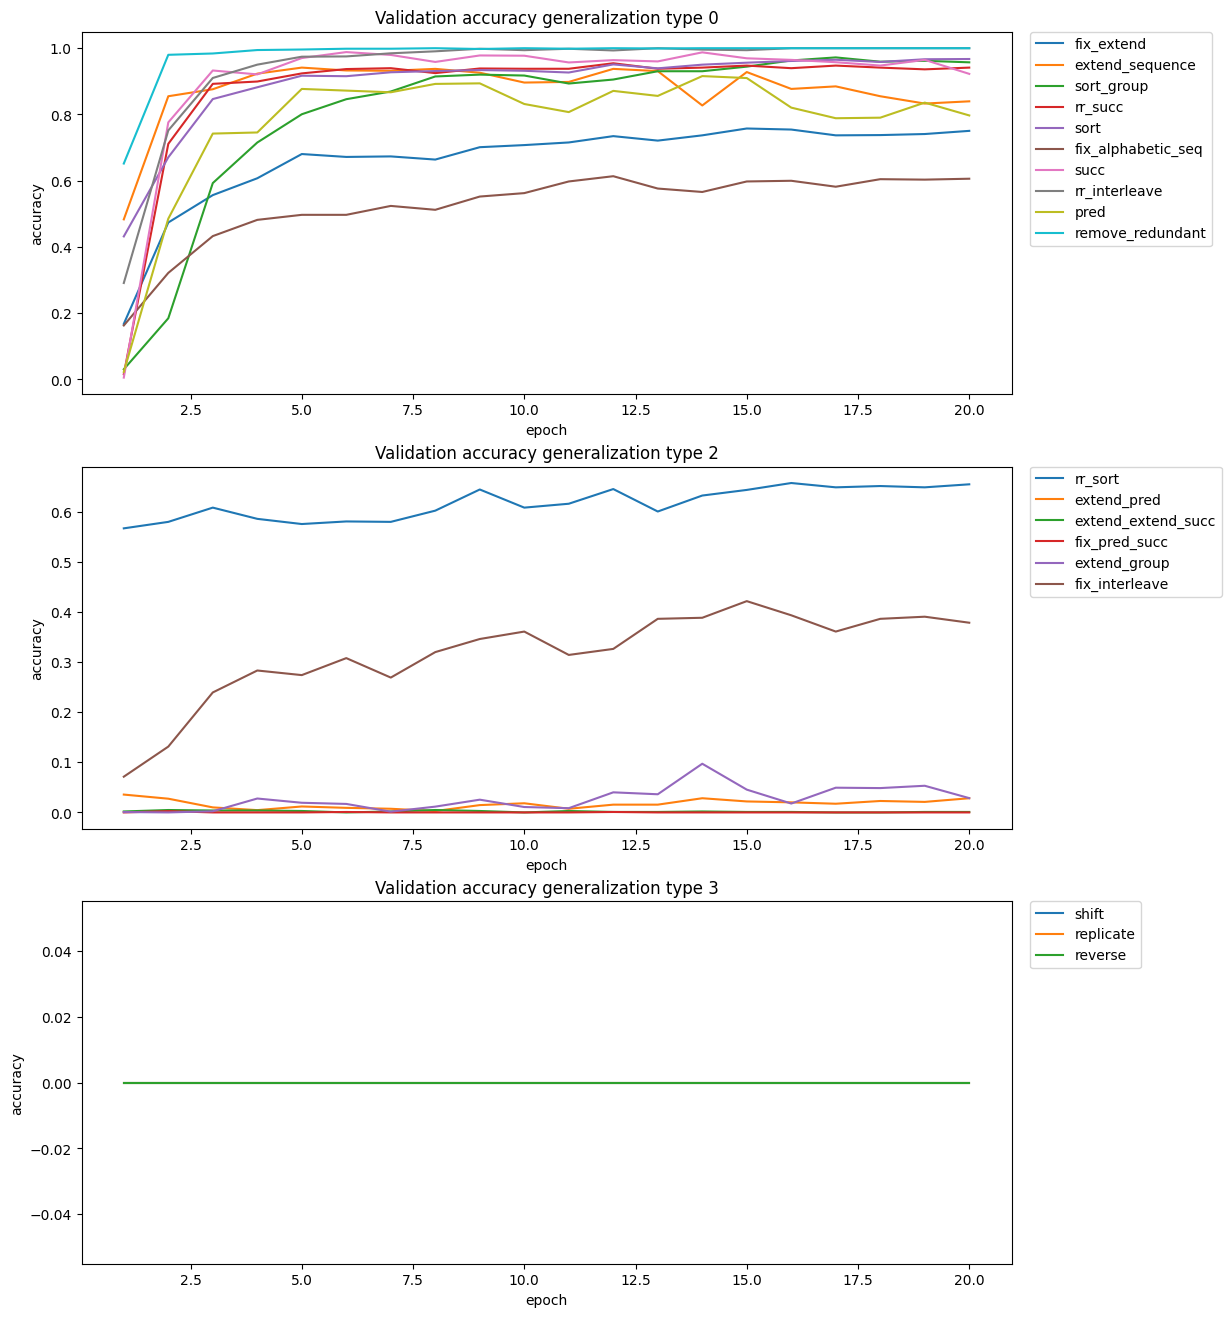

In [ ]:
_ = analysis_utils.training_information(by_both, val_loader, "Training History, Batching: unstructured")